# AI News Research and Summarization Agent  
Identify the type of query and then act accordingly

In [151]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field
from typing import Annotated, TypedDict, Literal

from dotenv import load_dotenv


In [152]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=1024
)

In [153]:
class NewsState(TypedDict):
    query: str

    query_type: Literal["research", "explain", "compare"]
    answer: str
    summary: str
    quality: Literal["good", "poor"]



In [154]:
class QueryAnalyzer(BaseModel):
    query_type: Literal["research", "explain", "compare"] = Field(description="Type of query")

class SummaryQualityAnalyzer(BaseModel):
    quality: Literal["poor", "good"] = Field(description="Judge the type of summary")


In [155]:
query_analyzer_llm = llm.with_structured_output(QueryAnalyzer)
summary_quality_analyzer_llm = llm.with_structured_output(SummaryQualityAnalyzer)

In [156]:
def analyze_query(state: NewsState) -> dict:
    prompt = f"""
    Identify the type of query : {state["query"]}
    Types should be either one of the following:
    research: Query asks some questions related to latest news
    explain: Query needs some explanation for a particular question
    compare: Query needs comparison between two or more entities
    """

    query_type = query_analyzer_llm.invoke(prompt).query_type

    return {"query_type": query_type}

In [157]:
def check_query_type(state: NewsState) -> Literal["research_response", "explain_response", "compare_response"]:

    if state["query_type"] == "research": 
        return "research_response"

    elif state["query_type"] == "explain":
        return "explain_response"
    
    else:
        return "compare_response"

In [158]:
def research_response(state: NewsState) -> dict:

    prompt = f"""
    Research and provide answer to the query: {state["query"]}
    """

    answer = llm.invoke(prompt).content

    return {"answer": answer}

In [159]:
def explain_response(state: NewsState) -> dict:

    prompt = f"""
    Explain the answer to the query in detail: {state["query"]}
    """

    answer = llm.invoke(prompt).content

    return {"answer": answer}

In [160]:
def compare_response(state: NewsState) -> dict:

    prompt = f"""
    Compare the entities mentioned in the query and provide answer: {state["query"]}
    """

    answer = llm.invoke(prompt).content

    return {"answer": answer}

In [161]:
def create_summary(state: NewsState) -> dict:

    prompt = f"""
    Generate a structured and sufficient summary for the answer: {state["answer"]}
    """

    summary = llm.invoke(prompt).content

    return {"summary": summary}

In [162]:
def judge_answer(state: NewsState) -> dict:

    prompt = f"""
    Judge the answer for the query: 
    Query: {state["query"]}
    Answer: {state["answer"]}
    """

    quality = summary_quality_analyzer_llm.invoke(prompt).quality

    return {"quality": quality}

In [163]:
def check_quality(state: NewsState) -> Literal["good_summary", "poor_summary"]:
    if state["quality"] == "good":
        return "good_summary"
    else:
        return "poor_summary"

In [164]:
def improve_answer(state: NewsState) -> dict:

    prompt = f"""
    Improvise the answer to the particular question
    Query: {state["query"]}
    Current Answer: {state["answer"]}
    
    You may improvise content, details, specifications, etc.
    Return the improved answer
    """

    answer = llm.invoke(prompt).content
    return {"answer": answer}

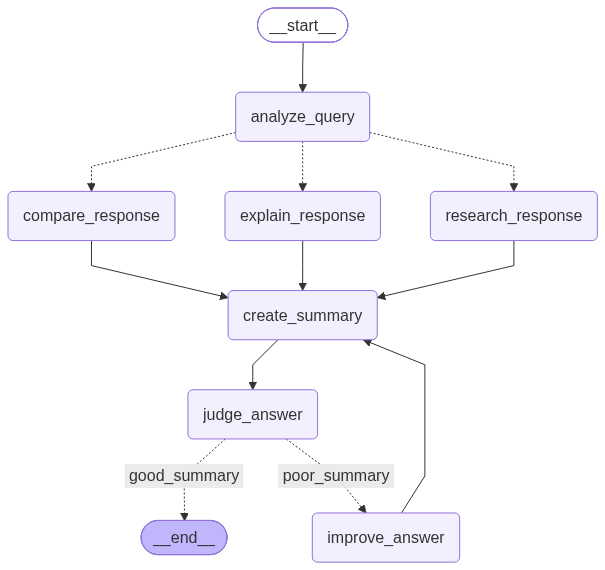

In [165]:
graph = StateGraph(NewsState)

graph.add_node("analyze_query", analyze_query)

graph.add_node("research_response", research_response)
graph.add_node("explain_response", explain_response)
graph.add_node("compare_response", compare_response)

graph.add_node("create_summary", create_summary)
graph.add_node("judge_answer", judge_answer)
graph.add_node("improve_answer", improve_answer)


graph.add_edge(START, "analyze_query")
graph.add_conditional_edges("analyze_query", check_query_type)
graph.add_edge("research_response", "create_summary")
graph.add_edge("explain_response", "create_summary")
graph.add_edge("compare_response", "create_summary")

graph.add_edge("create_summary", "judge_answer")

graph.add_conditional_edges(
    "judge_answer",
    check_quality,
    {
        "good_summary": END,
        "poor_summary": "improve_answer"
    }
)

graph.add_edge("improve_answer","create_summary")
graph.add_edge("create_summary", END)

workflow = graph.compile()
workflow

In [166]:
input_state = {
    "query": "Explain transformers in AIML in detail"
}

output_state = workflow.invoke(input_state)

output_state

{'query': 'Explain transformers in AIML in detail',
 'query_type': 'explain',
 'answer': '### Transformers in AI – A Deep Dive\n\n> **TL;DR**  \n> Transformers are a family of neural‑network architectures that rely on *self‑attention* to process sequences of data (text, images, audio, etc.). They eschew recurrence and convolution in favour of parallel, attention‑based computations, enabling state‑of‑the‑art performance on a wide range of AI tasks—from language modelling to image generation.\n\n---\n\n## 1. The Problem They Solve\n\nTraditional sequence‑to‑sequence models used **Recurrent Neural Networks (RNNs)** or **Long Short‑Term Memory (LSTM)** units. While powerful, these architectures suffer from:\n\n| Issue | Why it matters |\n|-------|----------------|\n| **Sequential processing** | Training is slow; inference is linear in sequence length. |\n| **Long‑range dependencies** | Gradients vanish/explode, making it hard to capture far‑away relationships. |\n| **Parallelism limits** |

In [167]:
print(output_state["answer"])

### Transformers in AI – A Deep Dive

> **TL;DR**  
> Transformers are a family of neural‑network architectures that rely on *self‑attention* to process sequences of data (text, images, audio, etc.). They eschew recurrence and convolution in favour of parallel, attention‑based computations, enabling state‑of‑the‑art performance on a wide range of AI tasks—from language modelling to image generation.

---

## 1. The Problem They Solve

Traditional sequence‑to‑sequence models used **Recurrent Neural Networks (RNNs)** or **Long Short‑Term Memory (LSTM)** units. While powerful, these architectures suffer from:

| Issue | Why it matters |
|-------|----------------|
| **Sequential processing** | Training is slow; inference is linear in sequence length. |
| **Long‑range dependencies** | Gradients vanish/explode, making it hard to capture far‑away relationships. |
| **Parallelism limits** | GPUs can’t fully exploit parallel compute because each token depends on the previous one. |

Transformer

In [168]:
print(output_state["summary"])

**Transformers in AI – Concise Summary**

| Section | Key Take‑aways |
|---------|----------------|
| **TL;DR** | Transformers are attention‑based neural architectures that process entire sequences in parallel, replacing costly recurrent or convolutional layers. They deliver state‑of‑the‑art results across text, vision, audio, and more. |
| **Problem Solved** | Traditional RNN/LSTM models: <br>• **Sequential** → slow training/inference.<br>• **Long‑range dependencies** → gradient vanishing/exploding.<br>• **Limited GPU parallelism**. <br>Transformers overcome all three by: <br>• Parallel sequence processing.<br>• Direct pairwise token interactions via self‑attention.<br>• Fully parallel feed‑forward layers. |
| **Core Building Blocks** | 1. **Self‑Attention** – Scaled dot‑product: `Attention(Q,K,V) = softmax(QKᵀ/√d_k) V`. <br>   *Q, K, V* are learned linear projections; each token attends to all others. <br>2. **Multi‑Head Attention** – `H` parallel heads compute attention in distinct 